In [20]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df.groupby("Target")["Admission grade"].mean()

Target
Dropout     124.961365
Enrolled    125.534257
Graduate    128.794432
Name: Admission grade, dtype: float64

In [4]:
df.groupby("Target")["Age at enrollment"].mean()

Target
Dropout     26.068966
Enrolled    22.369018
Graduate    21.783612
Name: Age at enrollment, dtype: float64

In [6]:
df.groupby("Target")["Age at enrollment"].median()

Target
Dropout     23.0
Enrolled    20.0
Graduate    19.0
Name: Age at enrollment, dtype: float64

In [8]:
df["Age at enrollment"].describe()

count    4424.000000
mean       23.265145
std         7.587816
min        17.000000
25%        19.000000
50%        20.000000
75%        25.000000
max        70.000000
Name: Age at enrollment, dtype: float64

In [9]:
df.groupby("Target")["Curricular units 1st sem (approved)"].mean()

Target
Dropout     2.551724
Enrolled    4.318640
Graduate    6.232232
Name: Curricular units 1st sem (approved), dtype: float64

In [10]:
df.groupby("Target")["Curricular units 2nd sem (approved)"].mean()

Target
Dropout     1.940183
Enrolled    4.057935
Graduate    6.177003
Name: Curricular units 2nd sem (approved), dtype: float64

### Academic performance by outcome

Students who graduate tend to pass more curricular units in both the first and second semesters.

- Dropout students pass around 2-3 units on average.
- Enrolled students pass around 4 units.
- Graduate students pass around 6 units.

This suggets that early academic performance may be an important predictor of student outcome.

In [12]:
df["Dropout_Risk"] = df["Target"].apply(lambda x: 1 if x == "Dropout" else 0)

In [13]:
df["Dropout_Risk"].value_counts()

Dropout_Risk
0    3003
1    1421
Name: count, dtype: int64

In [14]:
early_features = [
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance\t",
    "Previous qualification",
    "Previous qualification (grade)",
    "Admission grade",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "Age at enrollment",
    "International",
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)"
]

X_early = df[early_features]
y = df["Dropout_Risk"]

In [15]:
X_early.shape

(4424, 21)

In [16]:
y.shape

(4424,)

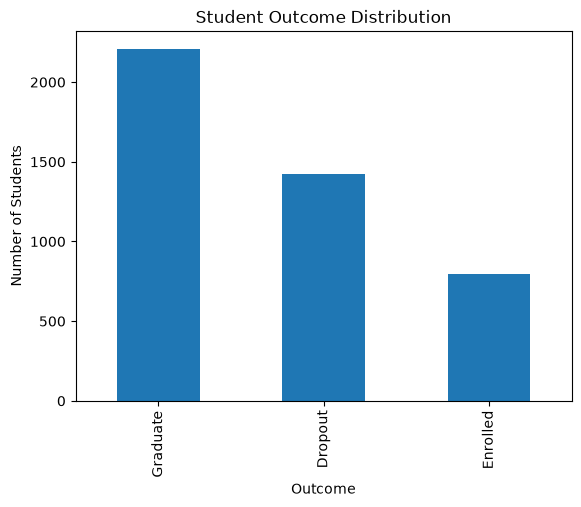

In [21]:
import matplotlib.pyplot as plt

df["Target"].value_counts().plot(kind="bar")

plt.title("Student Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Students")

plt.show()

In [22]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [24]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [25]:
df.shape

(4424, 37)

In [2]:
import pandas as pd

df = pd.read_csv("../data/data.csv", sep=";")

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
